## Анализ задержек рейсов (данные BTS/DOT, 2024)

### Вопросы:

- Какая средняя задержка прилёта?
- Как распределены задержки? (гистограмма)
- Есть ли маршруты, где задержки почти всегда? Какая — самая непунктуальная?
- По каким причинам чаще всего возникают задержки?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('flight_data_2024.csv', parse_dates=['fl_date'])


C:\Users\79524_wpxtvz5\AppData\Local\Temp\ipykernel_16120\3520224207.py:5: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('flight_data_2024.csv', parse_dates=['fl_date'])


In [2]:
#Поиск дубликатов
duplicates = df.duplicated().sum()
if duplicates == 0:
    result = 'Дубликаты не найдены'
else: 
    result = f'Дубли строк: {duplicates}'
print(result)

#Сравниваю количество аэропортов
dest_cnt = df['dest'].nunique()
origin_cnt = df['origin'].nunique()
print(f"Количество аэропортов отправления: {origin_cnt}")
print(f"Количество аэропортов прибытия: {dest_cnt}")

# Проверяю колонки 'origin' и 'dest' на симметричность
if set(df['origin']) == set(df['dest']):
    result = 'Данные по аэропортам симметричны'
else:
    result = 'Названия аэропортов отправления и прибытия не совпадают'
print(result)        


Дубликаты не найдены
Количество аэропортов отправления: 348
Количество аэропортов прибытия: 348
Данные по аэропортам симметричны


In [3]:
# Проверяю типы данных по задержке рейсов отправления и прибытия
print(f"Задержка вылета: {df['dep_delay'].info()}")
print(f"Задержка прилета: {df['arr_delay'].info()}")

<class 'pandas.Series'>
RangeIndex: 7079081 entries, 0 to 7079080
Series name: dep_delay
Non-Null Count    Dtype  
--------------    -----  
6986111 non-null  float64
dtypes: float64(1)
memory usage: 54.0 MB
Задержка вылета: None
<class 'pandas.Series'>
RangeIndex: 7079081 entries, 0 to 7079080
Series name: arr_delay
Non-Null Count    Dtype  
--------------    -----  
6965267 non-null  float64
dtypes: float64(1)
memory usage: 54.0 MB
Задержка прилета: None


In [4]:
#Проверяю пропуски в колонке 'cancelled'
cancelled_nan = df['cancelled'].isna().sum()
print(f"Количество пропусков в 'cancelled': {cancelled_nan}")

#Считаю сколько отмененных рейсов имеют данные по задержке
anomalies1 = df[(df['cancelled'] == 1) & (df['arr_delay'].isna() | df['dep_delay'].isna())].shape[0]
print(f"Количество отмененных рейсов с данными по задержке(аномалия): {anomalies1}")

Количество пропусков в 'cancelled': 0
Количество отмененных рейсов с данными по задержке(аномалия): 96315


In [5]:
anomalies2 = df[
    (df['cancelled'] == 1) & 
    ((df['dep_delay'].notna()) | (df['arr_delay'].notna()))
]

print(f"Найдено аномалий: {len(anomalies2)}")
print(anomalies2[['fl_date','cancelled','dep_delay','arr_delay','dep_time','arr_time']].head(10))

Найдено аномалий: 3345
         fl_date  cancelled  dep_delay  arr_delay  dep_time  arr_time
5148  2024-01-01          1        3.0        NaN    2133.0       NaN
6267  2024-01-01          1        4.0        NaN    2115.0       NaN
9338  2024-01-01          1       -6.0        NaN     754.0       NaN
34378 2024-01-02          1       -6.0        NaN     724.0       NaN
34633 2024-01-02          1      111.0        NaN    2121.0       NaN
62694 2024-01-04          1       13.0        NaN    1238.0       NaN
62966 2024-01-04          1       -8.0        NaN     817.0       NaN
66635 2024-01-04          1       -3.0        NaN     757.0       NaN
68360 2024-01-04          1       25.0        NaN    1125.0       NaN
80516 2024-01-05          1       20.0        NaN    1230.0       NaN


Обнаружено два типа аномалий среди отменённых рейсов:

96315 рейса — имеют данные о задержке, но не имеют времени вылета. Это, вероятно, техническая особенность данных (ошибка заполнения или неполная запись).

3345 рейсов — имеют данные о задержке и время вылета, но не имеют времени прилёта. Это, вероятно, реальные случаи отмены рейса после вылета (возврат, перенаправление, техническая причина).

В общем счете аномалии занимают 1.4% от данных.
При расчёте статистики отмененные рейсы исключаю, так как они могут исказить результаты.

In [6]:
#Убираю из данных отмененные рейсы (~1.3%) и копирую таблицу без них, чтобы увидеть картину только по фактически выполненным рейсам
df_actual = df[df['cancelled'] == 0].copy()
#Заполняю пропуски '0'
df_actual['arr_delay'] = df_actual['arr_delay'].fillna(0)
df_actual['dep_delay'] = df_actual['dep_delay'].fillna(0)

In [7]:
# Считаю среднее время задержки вылета и прилета
avg_dep_delay = df_actual['dep_delay'].mean()
avg_arr_delay = df_actual['arr_delay'].mean()

# Считаю медиану задержки вылета и прилета
median_dep_d = df_actual['dep_delay'].median()
median_arr_d = df_actual['arr_delay'].median()

#Считаю стандартное отклонение задержки вылета и прилета
dep_std = np.std(df_actual['dep_delay'])
arr_std = np.std(df_actual['arr_delay'])

#Считаю максимальное время задержки вылета и прилета
dep_delay_max = df_actual['dep_delay'].max()
arr_delay_max = df_actual['arr_delay'].max()

print("Статистика задержки вылета:")
print(f"Среднее время: {round(avg_dep_delay,2)} минут.")
print(f"Медиана: {round(median_dep_d,2)} минут.")
print(f"Стандартное отклонение: {round(dep_std,2)} минут.")
print(f"Максимальное время задержки: {round(dep_delay_max,2)} минут.")
print()
print("Статистика задержки прилета:")
print(f"Среднее время: {round(avg_arr_delay,2)} минут.")
print(f"Медиана задержки: {round(median_arr_d,2)} минут.")
print(f"Стандартное отклонение: {round(arr_std,2)} минут.")
print(f"Максимальное время задержки: {round(arr_delay_max,2)} минут.")

Статистика задержки вылета:
Среднее время: 12.65 минут.
Медиана: -2.0 минут.
Стандартное отклонение: 55.97 минут.
Максимальное время задержки: 3777.0 минут.

Статистика задержки прилета:
Среднее время: 7.08 минут.
Медиана задержки: -6.0 минут.
Стандартное отклонение: 57.92 минут.
Максимальное время задержки: 3803.0 минут.


В среднем рейсы задерживаются на 7–13 минут, но медиана отрицательная — это значит, что половина рейсов вылетает и прилетает даже раньше расписания. Длинный хвост задержек (до 3800 минут) создаётся небольшим числом рейсов с экстремальными задержками, которые сильно увеличивают среднее.

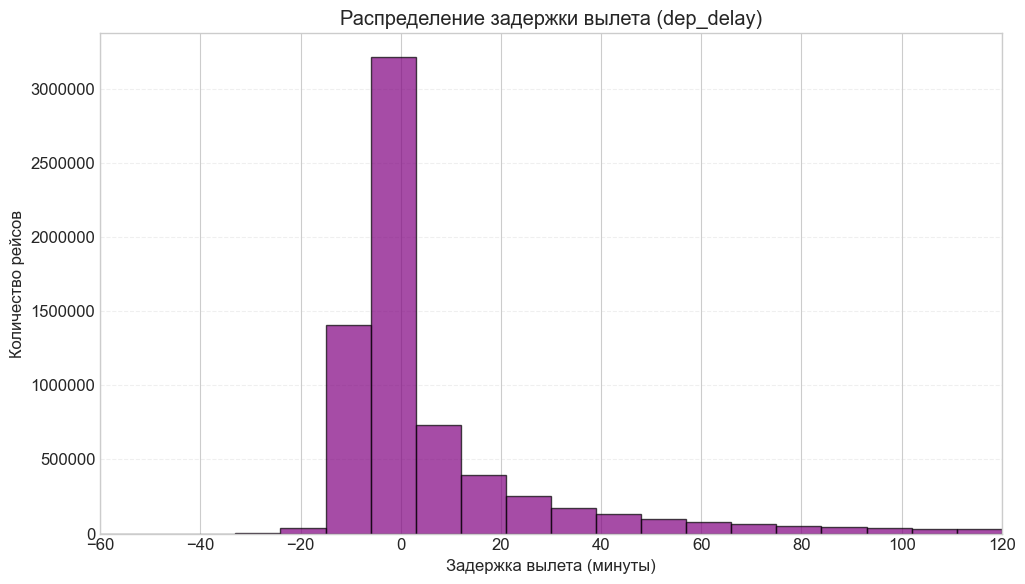

In [39]:
# Отфильтровываем задержки в нужном диапазоне
dep_delay_filtered = df['dep_delay'][(df['dep_delay'] >= -60) & (df['dep_delay'] <= 120)]

# Строим гистограмму распределения задержек
plt.style.use('seaborn-v0_8-whitegrid')  
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.hist(dep_delay_filtered, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Распределение задержки вылета (dep_delay)')
plt.xlabel('Задержка вылета (минуты)')
plt.ylabel('Количество рейсов')
plt.xlim(-60, 120)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.gca().ticklabel_format(style='plain', axis='y')
plt.show()

- Основная масса рейсов вылетает в диапазоне от −15 до +20 минут.
- Распределение имеет длинный правый хвост: есть рейсы с задержками более 60 минут, но их доля невелика, операционная дисциплина в целом хорошая
- Длинный правый хвост подтверждает, что средняя задержка (13мин) выше медианы (-2мин), из-за редких, но очень долгих задержек.

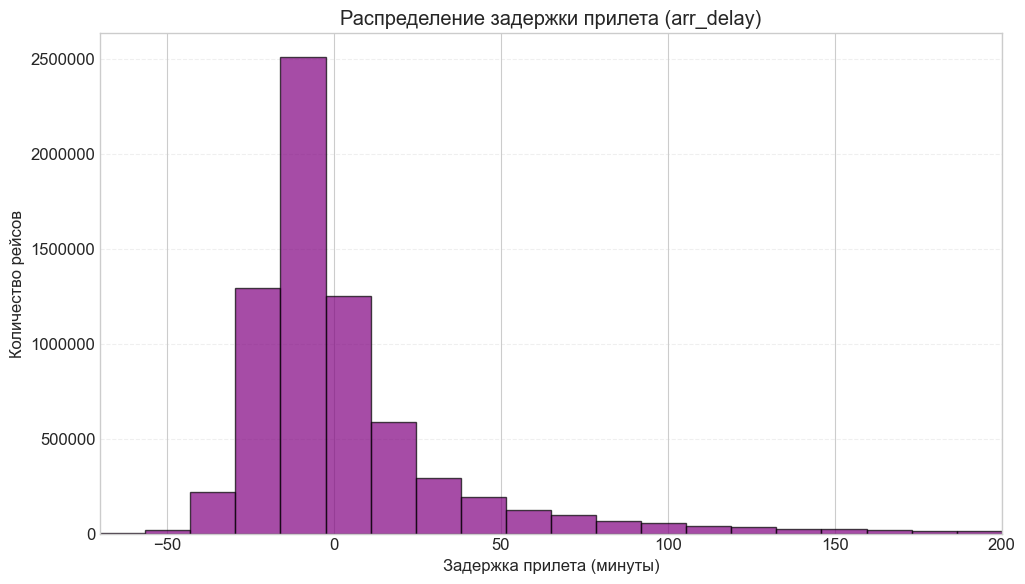

In [40]:
# Отфильтровываем задержки в нужном диапазоне
arr_delay_filtered = df['arr_delay'][(df['arr_delay'] >= -70) & (df['arr_delay'] <= 200)]

# Строим гистограмму распределения задержек прилета
plt.style.use('seaborn-v0_8-whitegrid')  
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.hist(arr_delay_filtered, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Распределение задержки прилета (arr_delay)')
plt.xlabel('Задержка прилета (минуты)')
plt.ylabel('Количество рейсов')
plt.xlim(-70, 200)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.gca().ticklabel_format(style='plain', axis='y')
plt.show()

- Основная масса рейсов прилетает с диапазоном от −30 до +30 минут задержки.
- Медианная задержка составляет −6 минут, что указывает на склонность рейсов прилетать раньше времени.
- Длинный правый хвост подтверждает, что средняя задержка (7мин) выше медианы (-6мин): значение смещено вправо за счёт редких, но экстремально долгих задержек (более 100 минут)


Какая авиакомпания самая непунктуальная?

In [13]:
#Сгруппирую данные по компаниям-перевозчикам
unique_carrier = df_actual.groupby('op_unique_carrier')

#Посчитаю количество рейсов
flights_cnt = unique_carrier.size()

#Посчитаю среднюю задержку прилета
avg_carrier_delay = unique_carrier['arr_delay'].mean()

#Посчитаю медиану
median_delay = unique_carrier['arr_delay'].median()

#Создаю таблицу "Среднее время задержки по перевозчикам (с количеством рейсов)"
merged = flights_cnt.reset_index().merge(
    avg_carrier_delay.reset_index(),
    on='op_unique_carrier',
    how='inner'
).merge(
    median_delay.reset_index(),
    on='op_unique_carrier',
    how='inner'
)
merged.columns = ['unique_carrier', 'flights', 'avg_delay','median']
merged = merged[merged['flights'] >= 100000].sort_values('avg_delay',ascending=False)
print("Среднее время задержки среди крупных перевозчиков (>100 000 рейсов):")
print(merged)

Среднее время задержки среди крупных перевозчиков (>100 000 рейсов):
   unique_carrier  flights  avg_delay  median
1              AA   969054  15.261506    -4.0
5              F9   203789  15.224801    -4.0
3              B6   236547  10.700415    -6.0
10             OH   224220  10.002324    -6.0
6              G4   115192   9.684249    -8.0
9              NK   256105   8.399809    -6.0
11             OO   736131   7.332958    -7.0
8              MQ   275970   6.442436    -6.0
12             UA   747973   5.726398    -7.0
13             WN  1407647   5.113997    -5.0
2              AS   241008   4.455159    -4.0
4              DL  1000047   3.649026    -8.0
0              9E   195486   1.678350   -11.0
14             YX   295889  -1.790813   -11.0


Среди крупных перевозчиков (более 100 000 рейсов за 2024 год) самая высокая средняя задержка прилёта у American Airlines — 15.2 минуты. При этом медиана у AA составляет -4 минуты, что означает: половина рейсов AA вылетает даже раньше расписания, но редкие и очень долгие задержки создают высокое среднее. 

Самая пунктуальная среди крупных — Republic Airlines (YX вылетает во время или раньше на 1.8 минут).

Есть ли маршруты, где задержки почти всегда?

In [31]:
# Поиск маршрутов с самой высокой долей задержки (>30 мин)
df_actual['route'] = df_actual['origin'] + '-' + df_actual['dest']

# Группирую данные (количество рейсов >10 500, задержка >30 минут) и вычисляю статистику
route_stats = df_actual.groupby('route')['arr_delay'].agg(['count','mean',lambda x: (x>30).mean() * 100])
route_stats.columns = ['total_flights', 'avg_delay', 'delay_pct(>30min)']
route_stats_filtred = route_stats[route_stats['total_flights'] > 10500]
route_stats_sorted = route_stats_filtred.sort_values('delay_pct(>30min)', ascending=False)
print("Топ-5 маршрутов с высокой долей задержки >30 минут:")
print(route_stats_sorted.head(5))


Топ-5 маршрутов с высокой долей задержки >30 минут:
         total_flights  avg_delay  delay_pct(>30min)
route                                               
LAX-SFO          11422  14.887848          20.985817
ORD-LGA          10743  10.380155          16.233827
SFO-LAX          11383   8.932707          15.628569
LGA-ORD          10727   5.585625          13.862217
OGG-HNL          11514   0.374240           5.184992


### Маршруты с задержками (> 10 500 рейсов за год - примерно 30% от всех рейсов на маршрут за год)
- LAX–SFO и SFO–LAX (маршрут между Лос-Анджелесом и Сан-Франциско) — самый загруженный и проблемный коридор. Каждый пятый рейс на этом направлении задерживается более чем на 30 минут. Это может быть связано с высокой интенсивностью воздушного движения и погодными условиями в Калифорнии.
- Нью-Йорк – Чикаго (ORD–LGA и LGA–ORD) — второй по частоте проблем маршрут с долей задержек 14–16%. Вероятные причины: загруженность аэропортов и погодные условия на северо-востоке США.
- OGG–HNL (Гавайи) — самый пунктуальный маршрут среди топ-5. Несмотря на большое количество рейсов, доля задержек > 30 мин составляет всего 5.2%. Это говорит о стабильной работе на островных направлениях, возможно, из-за более предсказуемых погодных условий.
- Средняя задержка на всех проблемных маршрутах не превышает 15 минут, что указывает на то, что большинство рейсов прибывают вовремя или с небольшой задержкой, но на маршрутах LAX–SFO и ORD–LGA есть устойчивая доля рейсов с существенными опозданиями.

## По каким причинам чаще всего возникают задержки?

In [32]:
# Поиск пропусков в колонках с причинами
search_nan = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].isna().sum() 
print("Количество пропусков в причинах:") 
print(search_nan)

Количество пропусков в причинах:
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64


In [33]:
# Считаю, сколько минут составила задержка по каждой причине
reasons_sum = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].sum()
print("Сколько минут составила задержка по каждой причине:") 
print(reasons_sum.sort_values(ascending=False))

Сколько минут составила задержка по каждой причине:
late_aircraft_delay    41974007
carrier_delay          35823265
nas_delay              19621994
weather_delay           6195873
security_delay           179928
dtype: int64


Большинство задержек (~75%) вызваны двумя причинами — задержкой предыдущего рейса и проблемами авиакомпании.
Это означает, что основные рычаги влияния на пунктуальность находятся внутри авиакомпаний и их операционной логистики.

In [34]:
#Считаю среднюю задержку по каждой причине
reasons_mean = df_actual[['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']].apply(lambda x: x[x>0].mean())
print("Cредняя задержка по каждой причине (мин):") 
print(reasons_mean.sort_values(ascending=False))

Cредняя задержка по каждой причине (мин):
weather_delay          69.690940
late_aircraft_delay    56.476265
carrier_delay          45.405392
nas_delay              27.034056
security_delay         24.294896
dtype: float64


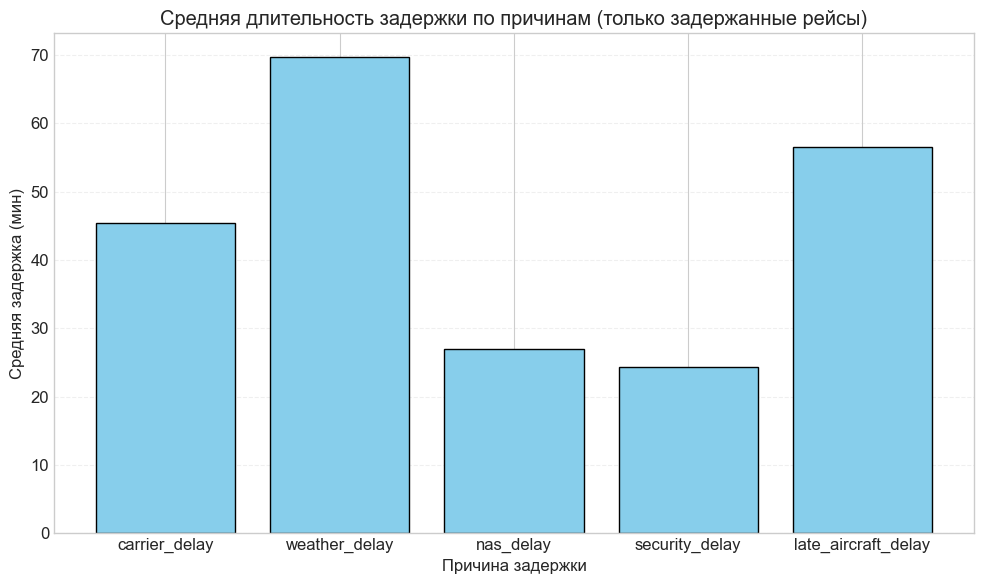

In [35]:
plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

plt.figure(figsize=(10, 6))
plt.bar(reasons_mean.index, reasons_mean.values, color='skyblue', edgecolor='black')
plt.title('Средняя длительность задержки по причинам (только задержанные рейсы)')
plt.xlabel('Причина задержки')
plt.ylabel('Средняя задержка (мин)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

При плохих погодных условиях - задержка рейсов в среднем на 1 час 15 минут. Это самые долгие задержки, но их не так много. 

Основной объём задержек создают задержка предыдущего рейса и проблемы авиакомпании.